In [11]:
import numpy as np

In [4]:
def jacobi_preconditioned_conjugate_gradient(A: np.ndarray, b: np.ndarray, x0: np.ndarray = None, tol: float = 1e-10, max_iter: int = 1000) -> np.ndarray:
    """
    Solve the linear system Ax = b using the Jacobi Preconditioned Conjugate Gradient method.
    Parameters:
    A : np.ndarray
        Symmetric positive-definite matrix.
    b : np.ndarray
        Right-hand side vector.
    x0 : np.ndarray, optional
        Initial guess for the solution (default is a zero vector).
    tol : float, optional
        Tolerance for convergence (default is 1e-10).
    max_iter : int, optional
        Maximum number of iterations (default is 1000).
    """

    # number of rows
    n = A.shape[0]

    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    r = b - A @ x
    M_inv = 1 / np.diag(A)  # Jacobi preconditioner (inverse of diagonal elements)
    z = M_inv * r
    p = z.copy()
    rs_old = np.dot(r, z)

    for i in range(max_iter):
        Ap = A @ p
        alpha = rs_old / np.dot(p, Ap)

        x = x + alpha * p
        r = r - alpha * Ap
        
        z = M_inv * r
        rs_new = np.dot(r, z)
        if np.sqrt(rs_new) / np.sqrt(rs_old) < tol:
            print("Converged")
            break

        beta = rs_new / rs_old

        p = z + beta * p

        rs_old = rs_new

    return x   

# Example usage
if __name__ == "__main__":
    # Define a symmetric positive-definite matrix A and vector b
    A = np.array([[4, 1], [1, 3]], dtype=float)
    b = np.array([1, 2], dtype=float)

    # Solve for x in Ax = b
    import time
    start_time = time.time()
    x = jacobi_preconditioned_conjugate_gradient(A, b)
    end_time = time.time()
    print("Time taken:", (end_time - start_time) / 60, "minutes")
    assert np.allclose(x, np.array([0.090909, 0.636364]))
    print("Solution x:", x)

Converged
Time taken: 2.8220812479654946e-05 minutes
Solution x: [0.09090909 0.63636364]


In [12]:
def check_spd_properties(A: np.ndarray) -> None:
    print(f"Matrix shape: {A.shape}")
    print(f"Matrix:\n{A}\n")

    # Check symmetry
    is_sym = np.allclose(A, A.T, atol=1e-10)
    print(f"✓ Symmetric: {is_sym}")

    # Check SPD via eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    print(f"Eigenvalues: {eigvals}")
    is_spd = np.all(eigvals > 1e-10)
    print(f"✓ Positive definite (all eigenvalues > 0): {is_spd}")

    # Condition number
    if is_spd:
        cond_num = np.max(eigvals) / np.min(eigvals)
        print(f"Condition number: {cond_num:.2e}")

    # Check diagonal dominance
    diag = np.diag(A)
    row_sums = np.sum(np.abs(A), axis=1) - np.abs(diag)
    is_dd = np.all(np.abs(diag) > row_sums)
    print(f"✓ Diagonally dominant: {is_dd}")

In [3]:
def load_matrix_from_binary_check_spd(file_path: str) -> None:
    """Load a square matrix from a binary file with the specified format.
       the function to check the dense matrix properties: symmetric, SPD, condition number, diagonal dominance.
    """
    with open("../data/matrix.bin", "rb") as f:
        n_rows = np.fromfile(f, dtype=np.int32, count=1)[0]
        n_cols = np.fromfile(f, dtype=np.int32, count=1)[0]
        assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
        A = np.fromfile(f, dtype=np.float64, count=n_rows * n_cols).reshape(n_rows, n_cols)

    check_spd_properties(A)

In [13]:
DATA_PATH = "../data/"

matrix_bin_path = DATA_PATH + "matrix_dense.bin"
matrix_mtx_path = DATA_PATH + "matrix_csr.mtx"

In [ ]:
# check the properties of the matrix loaded from the .bin file
load_matrix_from_binary_check_spd(matrix_bin_path)

Matrix shape: (13824, 13824)
Matrix:
[[50. -1.  0. ...  0.  0.  0.]
 [-1. 50. -1. ...  0.  0.  0.]
 [ 0. -1. 50. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 50. -1.  0.]
 [ 0.  0.  0. ... -1. 50. -1.]
 [ 0.  0.  0. ...  0. -1. 50.]]

✓ Symmetric: True


In [17]:
def load_matrix_from_mtx_and_check_spd(file_path: str) -> None:
    """Load a square matrix from a Matrix Market (.mtx) file int a compressed format."""
    from scipy.io import mmread
    A = mmread(file_path).toarray()
    n_rows, n_cols = A.shape
    assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
    
    check_spd_properties(A)

In [22]:
# check the properties of the matrix loaded from the .mtx file
load_matrix_from_mtx_and_check_spd(matrix_mtx_path)

Matrix shape: (1000, 1000)
Matrix:
[[ 3.1 -1.   0.  ...  0.   0.   0. ]
 [-1.   4.1 -1.  ...  0.   0.   0. ]
 [ 0.  -1.   4.1 ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ...  4.1 -1.   0. ]
 [ 0.   0.   0.  ... -1.   4.1 -1. ]
 [ 0.   0.   0.  ...  0.  -1.   3.1]]

✓ Symmetric: True
Eigenvalues: [ 0.1         0.19788697  0.19788697  0.19788697  0.29577393  0.29577393
  0.29577393  0.3936609   0.48196601  0.48196601  0.48196601  0.57985298
  0.57985298  0.57985298  0.57985298  0.57985298  0.57985298  0.67773995
  0.67773995  0.67773995  0.86393202  0.86393202  0.86393202  0.9244295
  0.9244295   0.9244295   0.96181899  0.96181899  0.96181899  1.02231646
  1.02231646  1.02231646  1.02231646  1.02231646  1.02231646  1.12020343
  1.12020343  1.12020343  1.24589803  1.30639551  1.30639551  1.30639551
  1.30639551  1.30639551  1.30639551  1.40428247  1.40428247  1.40428247
  1.40428247  1.40428247  1.40428247  1.48196601  1.48196601  1.48196601
  1.57985298  1.57985298  1.57985298  1.57985298 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
def compute_speedups(serial_time: list, parallel_times: list) -> list:
    """
    Compute speedups given serial and parallel execution times.
    Parameters:
        serial_time : Execution time of the serial implementation.
        parallel_times : Execution times of the parallel implementations.
    Returns:
        List of speedup values.
    """
    return [serial_time / t for t in parallel_times]

def compute_efficiencies(speedups: list, num_processors: list) -> list:
    """
    Compute efficiencies given speedups and number of processors.
    Parameters:
        speedups : List of speedup values.
        num_processors : List of number of processors used.
    Returns:
        List of efficiency values.
    """
    return [s / p for s, p in zip(speedups, num_processors)]

In [5]:
def plot_speedup_efficiency(
        file_path: str = "../output/jcgtimes.txt",
        title: str = "Block JCG", with_ideal: bool = True, with_min_time: bool = True,
        output_file_path: str = None) -> None:
    """
    Plot speedup and efficiency from timing data.
    Parameters:
        file_path : Path to the timing data file.
        title : Title for the plots.
        with_ideal : Whether to plot ideal speedup and efficiency lines.
        with_min_time : Whether the data file includes min_time column.
        output_file_path : Path to save the output plot (if None, display the plot).
    Returns:
        None
    """
    # Read the data
    results = {"grid_size": [], "num_processors": [], "min_time": [], "max_time": []}

    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            if with_min_time:
                grid, pros, max_time, min_time = line.strip().split()
            else:
                grid, pros, max_time = line.strip().split()
                min_time = max_time  # if min_time is not provided, use max_time as a placeholder
            # skp the first line since it contains headers
            if i == 0:
                continue
            results["grid_size"].append(int(grid))
            results["num_processors"].append(int(pros))
            results["min_time"].append(float(min_time))
            results["max_time"].append(float(max_time))
    results_df = pd.DataFrame(results)

    # Create figures
    plt.figure(figsize=(12, 6))
    plt.suptitle(f"Speedup and Efficiency for All Problem Sizes - {title}", fontsize=16)

    # Speedup plot
    plt.subplot(1, 2, 1)
    for size in results_df["grid_size"].unique():
        subset = results_df[results_df["grid_size"] == size]
        subset = subset.sort_values("num_processors")
        times = subset["max_time"].tolist()
        num_processors = subset["num_processors"].tolist()
        
        serial_time = times[0]
        speedups = compute_speedups(serial_time, times)
        plt.plot(num_processors, speedups, marker='*', label=f'Grid {size}')
    # ideal speedup line
    if with_ideal:
        ideal_speedup = list(range(1, max(results_df["num_processors"]) + 1))
        plt.plot(ideal_speedup, ideal_speedup, 'k--', label='Ideal Speedup')
    plt.title('Speedup vs Number of Processors')
    plt.xlabel('Number of Processors')
    plt.ylabel('Speedup')
    plt.xticks(num_processors)
    # plt.yticks(num_processors)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("../output/speedup_" + output_file_path) if output_file_path else None

    # Efficiency plot
    plt.subplot(1, 2, 2)
    for size in results_df["grid_size"].unique():
        subset = results_df[results_df["grid_size"] == size]
        subset = subset.sort_values("num_processors")
        times = subset["max_time"].tolist()
        num_processors = subset["num_processors"].tolist()
        
        serial_time = times[0]
        speedups = compute_speedups(serial_time, times)
        efficiencies = compute_efficiencies(speedups, num_processors)
        
        plt.plot(num_processors, efficiencies, marker='*', label=f'Grid {size}')
    # ideal efficiency line
    if with_ideal:
        ideal_efficiency = [1.0 for _ in range(1, max(results_df["num_processors"]) + 1)]
        plt.plot(ideal_speedup, ideal_efficiency, 'k--', label='Ideal Efficiency')
    plt.title('Efficiency vs Number of Processors')
    plt.xlabel('Number of Processors')
    plt.ylabel('Efficiency')
    plt.xticks(num_processors)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("../output/efficiency_" + output_file_path) if output_file_path else None
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


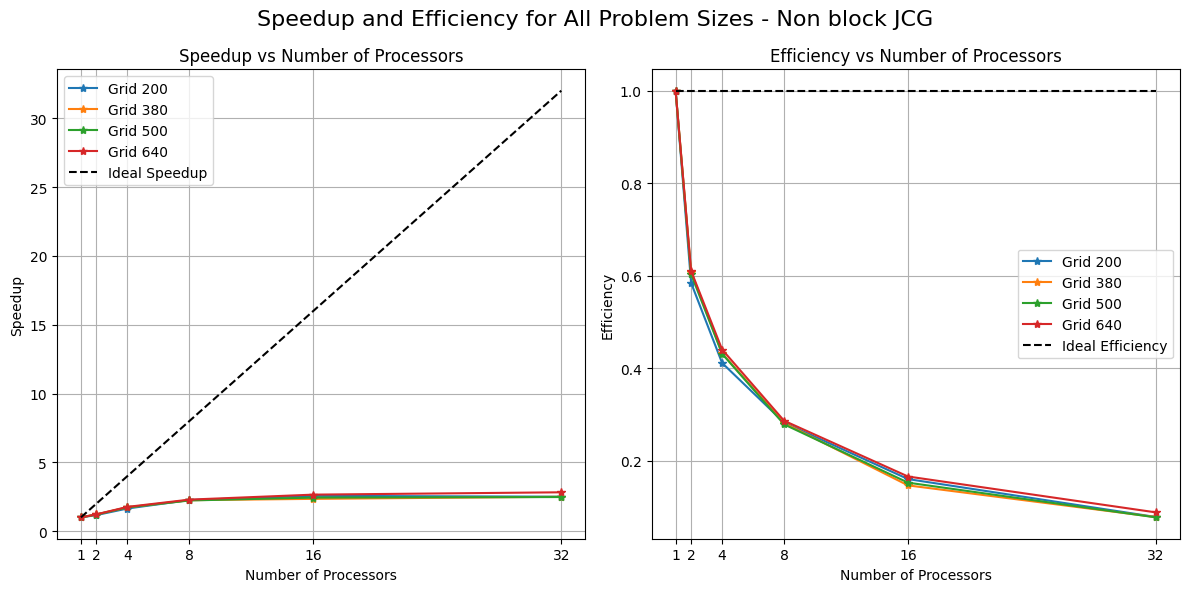

In [6]:
plot_speedup_efficiency(
    "../output/jcgtimes_nblock_old.txt", title="Non block JCG", with_ideal=True,
    output_file_path="non_block_jcg.eps"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


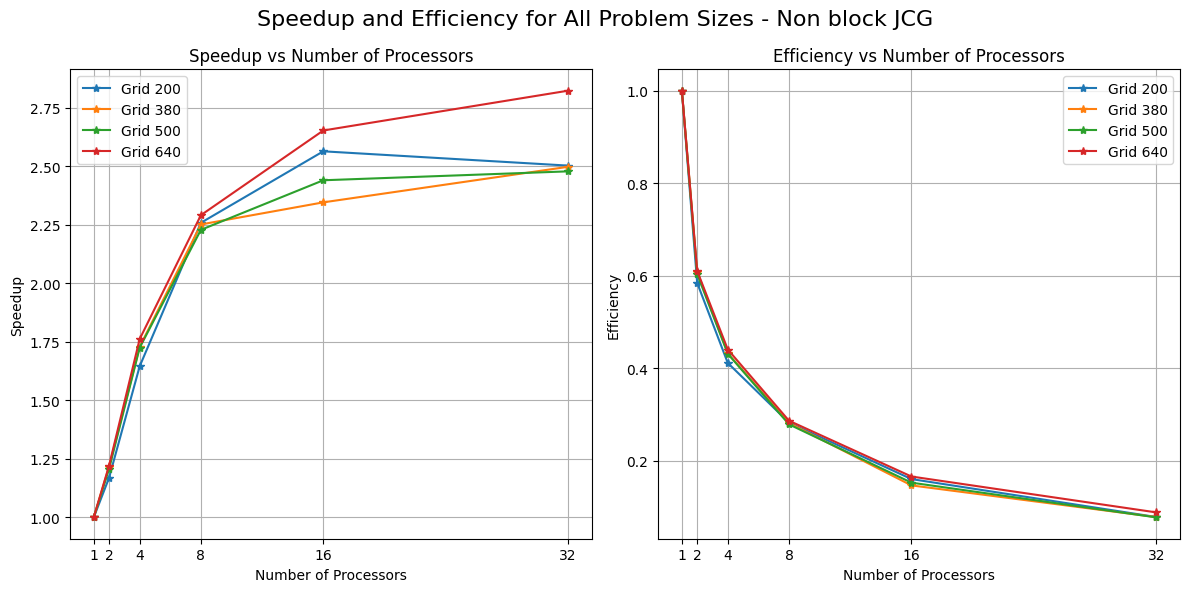

In [7]:
plot_speedup_efficiency(
    "../output/jcgtimes_nblock_old.txt", title="Non block JCG", with_ideal=False,
    output_file_path="non_block_jcg_no_ideal.eps"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


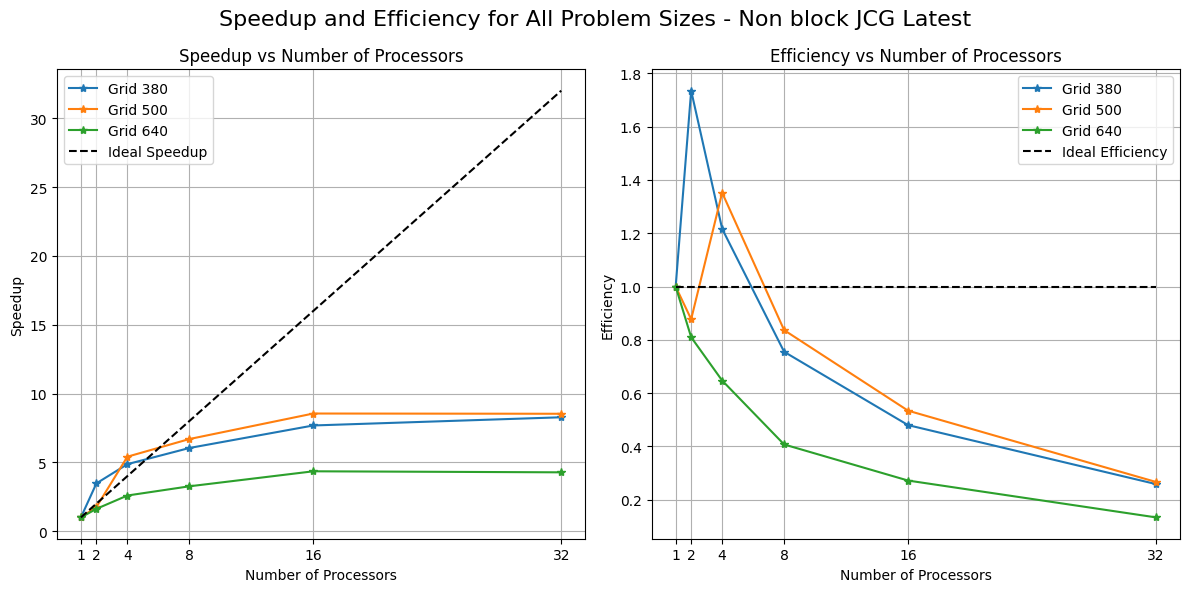

In [9]:
plot_speedup_efficiency(
    "../output/jcgtimes_nblock.txt", title="Non block JCG Latest", with_ideal=True,
    output_file_path="non_block_jcg_latest.eps"
)

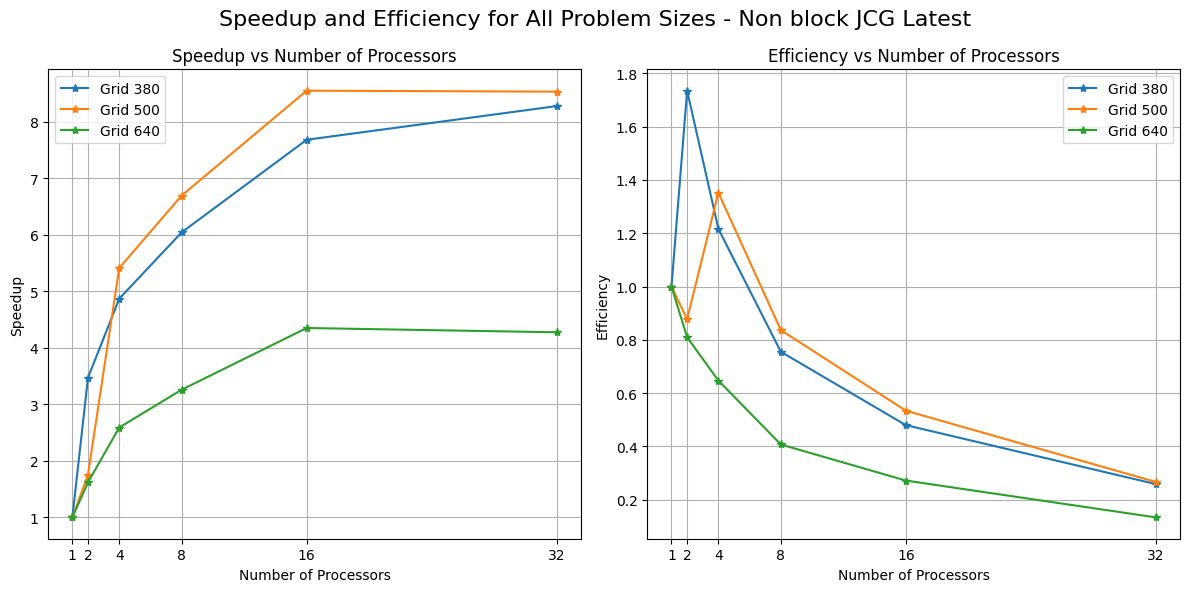

In [ ]:
plot_speedup_efficiency(
    "../output/jcgtimes_nblock.txt", title="Non block JCG Latest", with_ideal=False,
    output_file_path="non_block_jcg_latest_no_ideal.eps")

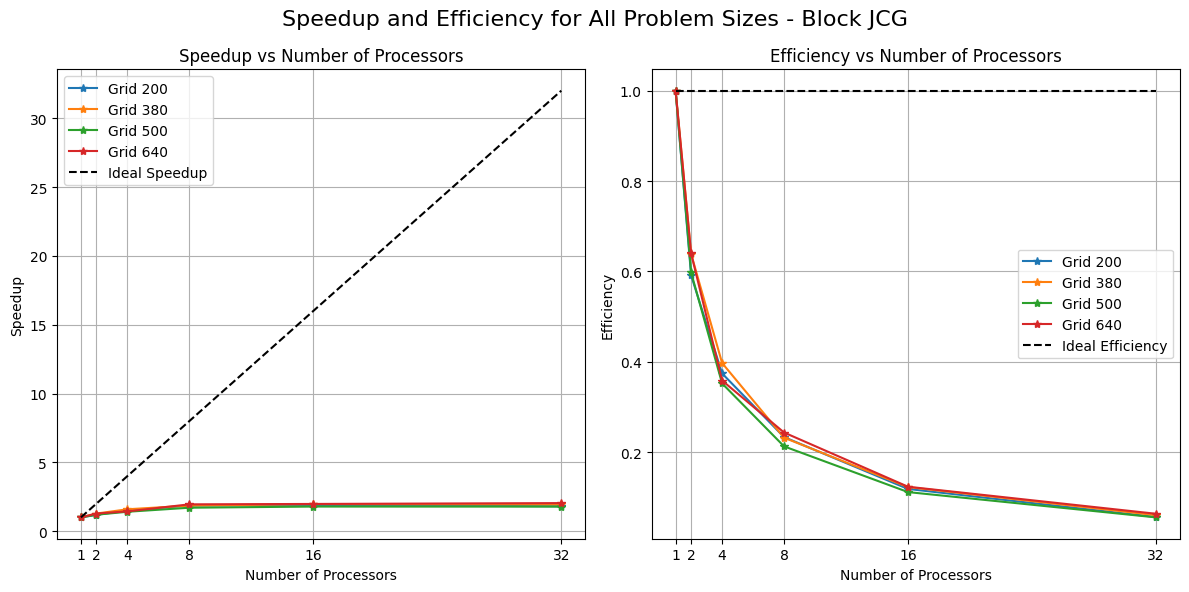

In [ ]:
plot_speedup_efficiency(
    "../output/jcgtimes_block_old.txt", title="Block JCG", with_ideal=True, with_min_time=False,
    output_file_path="block_jcg.eps"
)

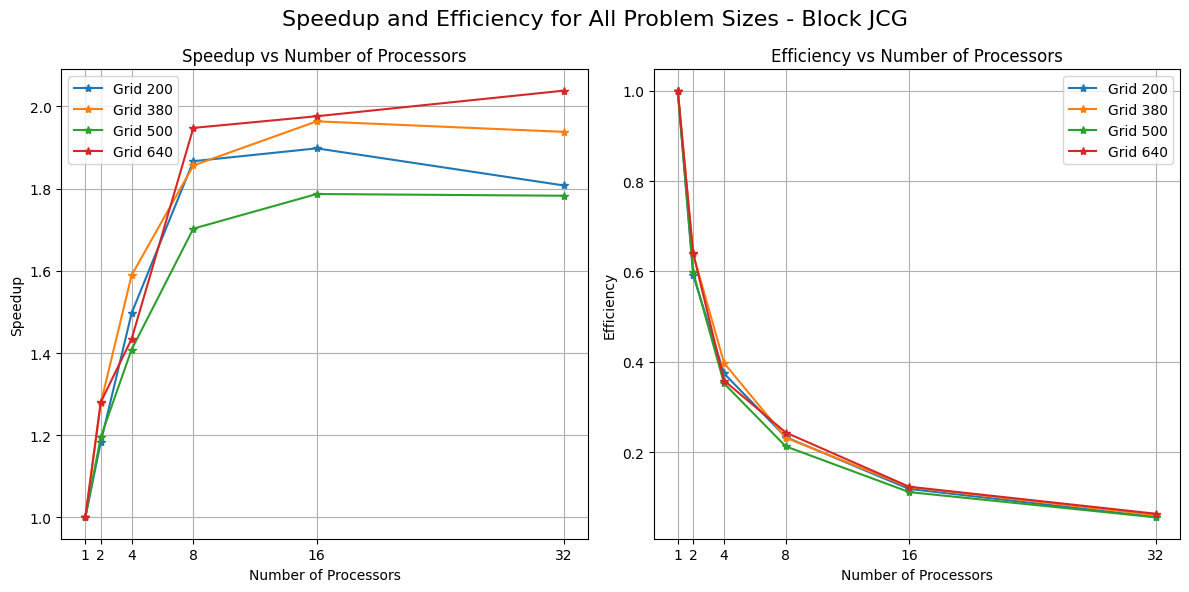

In [ ]:
plot_speedup_efficiency(
    "../output/jcgtimes_block_old.txt", title="Block JCG", with_ideal=False, with_min_time=False,
    output_file_path="block_jcg_no_ideal.eps"
)